In [1]:
# Importing the libraries
import warnings
warnings.filterwarnings("ignore")
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [2]:
#data sugmentation
# Preprocessing the Training set
datagen = ImageDataGenerator(rescale=1./255,validation_split=0.22)
training_set = datagen.flow_from_directory('train',
                                            target_size=(224,224),
                                            color_mode="rgb",
                                            subset="training",
                                            class_mode="binary",
                                            batch_size=32,
                                            shuffle=True)

Found 198 images belonging to 2 classes.


In [3]:
valid_generator=datagen.flow_from_directory( directory="train",
                                                target_size=(224,224),
                                                color_mode="rgb",
                                                subset="validation",
                                                class_mode="binary",
                                                batch_size=32,
                                                shuffle=True)

Found 55 images belonging to 2 classes.


In [4]:
## showing some image from training
import matplotlib.pyplot as plt
def plotImages(images_arr):
    fig, axes = plt.subplots(1, 5, figsize=(20, 20))
    axes = axes.flatten()
    for img, ax in zip(images_arr, axes):
        ax.imshow(img)
    plt.tight_layout()
    plt.show()

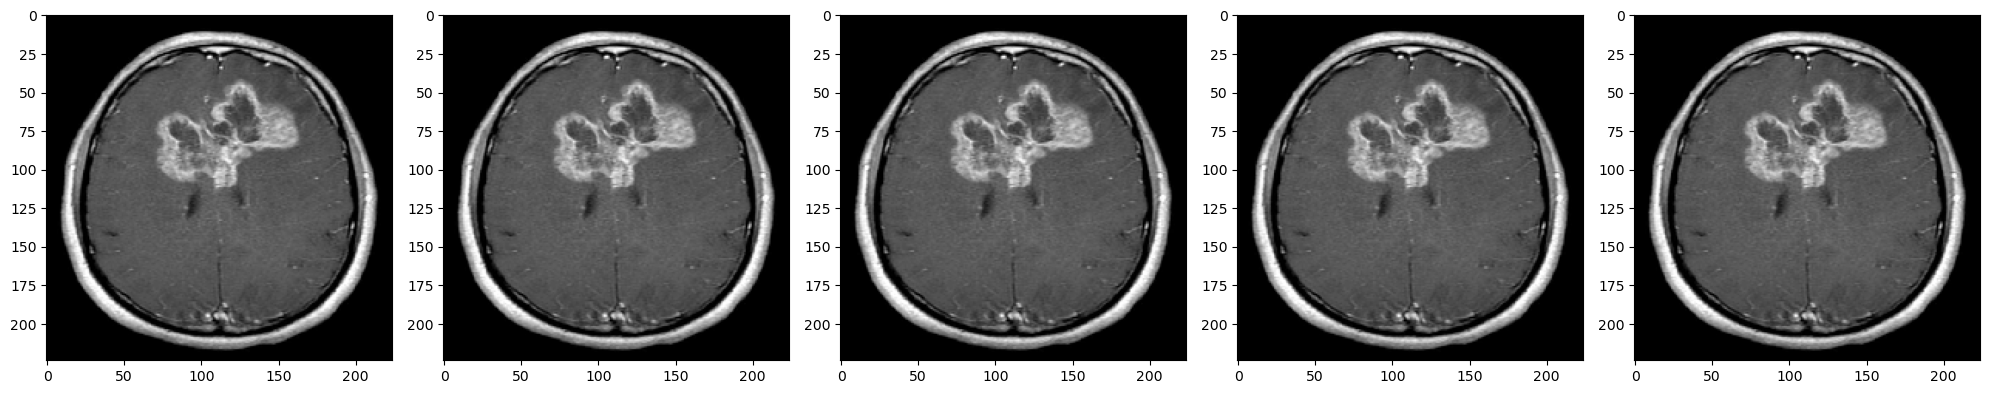

In [5]:
images = [training_set[0][0][0] for i in range(5)]
plotImages(images)

In [6]:
training_set.class_indices

{'no': 0, 'yes': 1}

In [7]:
import tensorflow_hub as hub 

In [8]:
BATCH_SIZE = 5
IMG_SHAPE = 224 # match image dimension to mobile net input keep smae

In [9]:
# getting MobileNet
URL = "https://tfhub.dev/google/tf2-preview/mobilenet_v2/feature_vector/4"
mobile_net = hub.KerasLayer(URL, input_shape=(IMG_SHAPE, IMG_SHAPE, 3))

In [10]:
mobile_net.trainable = False

In [11]:
model = tf.keras.models.Sequential([
    mobile_net,
    ### ann layer
    tf.keras.layers.Dense(1, activation='sigmoid') #[0, 1] or [1, 0]
    ])

In [12]:
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [13]:
history = model.fit(
    training_set,
    epochs=15,
    validation_data=valid_generator
    )

Epoch 1/15
7/7 [==============================] - 21s 2s/step - loss: 0.6430 - accuracy: 0.5960 - val_loss: 0.6140 - val_accuracy: 0.7091
Epoch 2/15
7/7 [==============================] - 13s 2s/step - loss: 0.6261 - accuracy: 0.6616 - val_loss: 0.5381 - val_accuracy: 0.7273
Epoch 3/15
7/7 [==============================] - 12s 2s/step - loss: 0.5084 - accuracy: 0.7576 - val_loss: 0.5500 - val_accuracy: 0.7455
Epoch 4/15
7/7 [==============================] - 12s 2s/step - loss: 0.4825 - accuracy: 0.7980 - val_loss: 0.4520 - val_accuracy: 0.8182
Epoch 5/15
7/7 [==============================] - 12s 2s/step - loss: 0.4354 - accuracy: 0.8030 - val_loss: 0.4322 - val_accuracy: 0.7818
Epoch 6/15
7/7 [==============================] - 12s 2s/step - loss: 0.4051 - accuracy: 0.8434 - val_loss: 0.3977 - val_accuracy: 0.8545
Epoch 7/15
7/7 [==============================] - 12s 2s/step - loss: 0.3747 - accuracy: 0.8687 - val_loss: 0.3775 - val_accuracy: 0.8545
Epoch 8/15
7/7 [==================

In [14]:
accuracy_at_15th_epoch = history.history['accuracy'][14]*100  # Assuming accuracy is a monitored metric

# Print the accuracy
print(f'Accuracy of the model: {accuracy_at_15th_epoch}%')

Accuracy of the model: 94.94949579238892%


In [15]:
# Part 4 - Making a single prediction test
import numpy as np
from tensorflow.keras.preprocessing import image
from sklearn.metrics import accuracy_score 
test_image = image.load_img('train/yes/Y1.jpg', target_size = (224,224))
test_image = image.img_to_array(test_image)
test_image=test_image/255
test_image = np.expand_dims(test_image, axis = 0)
result = model.predict(test_image)
print(result)



1/1 [==============================] - 1s 912ms/step
[[0.9827379]]


In [16]:
if result[0]<=0.5:
    print("No BrainTumor")
else:
    print("BrainTumor")

BrainTumor


In [17]:
#save model
from tensorflow.keras.models import load_model
model.save('brain_tumor.h5')

Found 253 images belonging to 2 classes.
8/8 [==============================] - 13s 2s/step
Confusion Matrix:
[[ 85  13]
 [  5 150]]


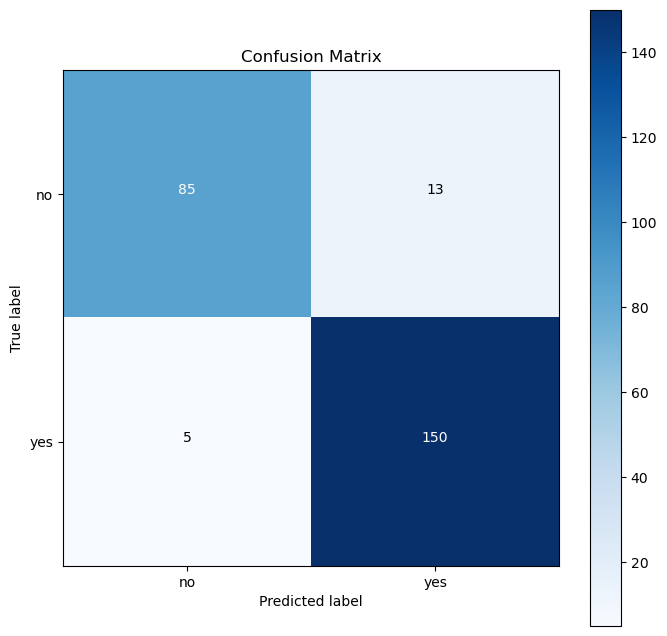

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Assuming you have a test set with images and true labels (0 for 'no', 1 for 'yes')
# Modify this according to your actual test set
test_set = datagen.flow_from_directory('train',  # Update this path
                                       target_size=(224, 224),
                                       color_mode='rgb',
                                       class_mode='binary',
                                       batch_size=32,
                                       shuffle=False)

# Get the true labels for the test set
true_labels = test_set.classes

# Make predictions on the test set
predicted_labels = model.predict(test_set)

# Convert predicted probabilities to binary predictions
predicted_labels_binary = (predicted_labels > 0.5).astype(int).flatten()

# Calculate the confusion matrix
conf_matrix = confusion_matrix(true_labels, predicted_labels_binary)

# Display the confusion matrix=
print("Confusion Matrix:")
print(conf_matrix)

# Plot the confusion matrix
classes = ['no', 'yes']
plt.figure(figsize=(8, 8))
plt.imshow(conf_matrix, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()

tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes)
plt.yticks(tick_marks, classes)

for i in range(len(classes)):
    for j in range(len(classes)):
        plt.text(j, i, str(conf_matrix[i][j]), horizontalalignment='center', color='white' if conf_matrix[i][j] > conf_matrix.max() / 2 else 'black')

plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()


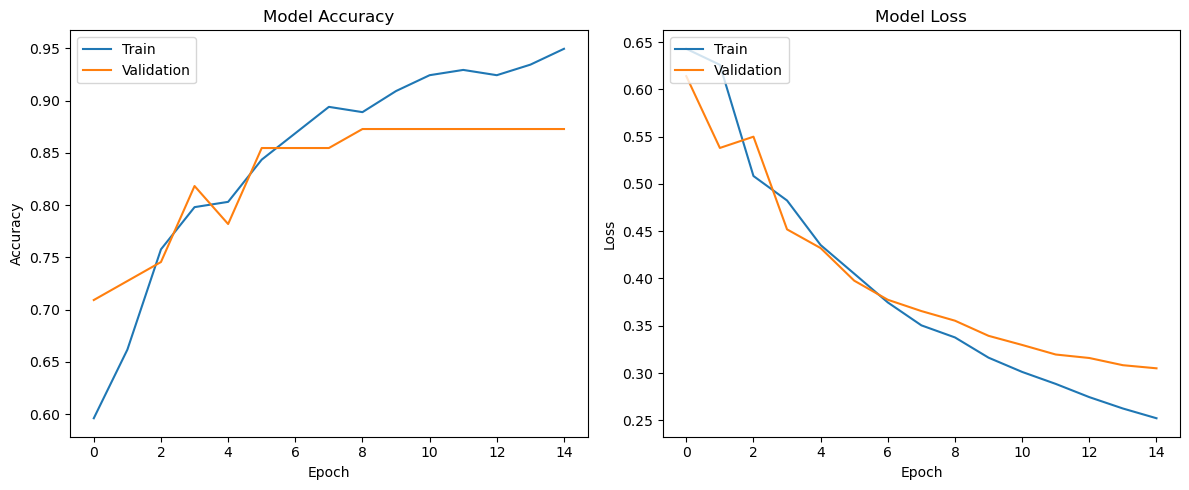

In [19]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()
